In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import geopandas as gpd
from pyproj import Transformer
from project.data_handling import * 
import pandas as pd

site_dict = {
    'wolverine':['N','B','EC'],
    'kahiltna':['K53','K17b'], 
    'kennicott':['GTL','GTH'], # ,'KC31'],
    'lemon_creek':['B','C','D'],
    'taku':['NWB1','TKG3'],
    'gulkana':['AU','B','D']
}

### Compare old shading masks (slow, individual point search) to new ones (GPU / vectorized)

FileNotFoundError: Could not find shadow file: /home/claire/Local/data/shading/01.09162_shadows.nc

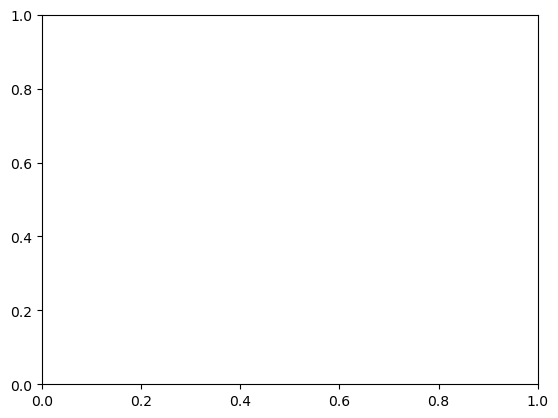

In [26]:
shading_fp = '/home/claire/Local/data/shading/'

# create figure
n_sites = np.sum([len(s) for _, s in site_dict.items()])
fig, ax = plt.subplots()
sites = []
i = 0
for glacier in site_dict:
    glacier_id = translate_rgi[glacier]['6']

    # load the shading file
    file_path = os.path.join(shading_fp, f"{glacier_id}_shadows.nc")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Could not find shadow file: {file_path}")

    ds = xr.open_dataset(file_path)

    # apply coordinate corrections as needed
    local_times = ds.time.values - np.timedelta64(8, "h")
    ds = ds.assign_coords(time=local_times)
    ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')
    ds = ds.rio.write_crs(ds['spatial_ref'].attrs['crs_wkt'])

    # read in the site constants file for this glacier
    df = pd.read_csv(f'data/by_glacier/{glacier}/site_constants.csv', index_col='site')

    for site in site_dict[glacier]:
        # grab lat/lon for this site and convert it to x/y
        point_to_grab = (df.loc[site, 'lat'], df.loc[site, 'lon'])
        transformer = Transformer.from_crs("EPSG:4326", ds.rio.crs, always_xy=True)
        x_pts, y_pts = transformer.transform(point_to_grab[1], point_to_grab[0])

        # get xr DataArrays for the slicing variables
        target_x = xr.DataArray([x_pts], dims='points')
        target_y = xr.DataArray([y_pts], dims='points')

        new_ds = ds.sel(y=target_y, x=target_x, method='nearest').shadow_mask

        # load the old shadow mask
        old_mask = pd.read_csv(f'data/by_glacier/{glacier}/shade/{glacier}{site}_shade.csv', parse_dates=True, index_col=0)
        old_mask['doy'] = old_mask.index.day_of_year
        old_mask['hour'] = old_mask.index.hour

        # load the new shadow mask into a dataframe identical to old_mask
        new_mask = new_ds.to_dataframe(name='shadow_mask').reset_index()
        new_mask['doy'] = pd.DatetimeIndex(new_mask['time']).day_of_year
        new_mask['hour'] = pd.DatetimeIndex(new_mask['time']).hour

        # merge on doy/hour
        comparison = old_mask.merge(new_mask[['doy', 'hour', 'shadow_mask']], 
                                    on=['doy', 'hour'], 
                                    suffixes=('_old', '_new'))

        # calculate error metrics
        old = ~comparison['shaded']
        new = comparison['shadow_mask']
        tp = (old & new).sum()        # both say shadowed
        tn = (~old & ~new).sum()      # both say lit
        fp = (~old & new).sum()       # old says lit, new says shadowed
        fn = (old & ~new).sum()       # old says shadowed, new says lit
        n = len(old)

        # plot stacked bar chart of errors
        ax.bar(i, (tp+tn)/n, color='green')
        ax.bar(i, fp/n, bottom=(tp+tn)/n, color='red')
        ax.bar(i, fn/n, bottom=(tp+tn)/n + fp/n, color='k')
        i+= 1
        sites.append(glacier.replace('_',' ')+' '+site)
ax.bar(0, np.nan, color='green', label='Agreement')
ax.bar(0, np.nan, color='red', label='False positive')
ax.bar(0, np.nan, color='k', label='False negative')
ax.legend(bbox_to_anchor=(1.02, 0.5))
ax.set_xticks(range(n_sites))
ax.set_xticklabels(sites, rotation=45, ha='right')
ax.set_title('Comparison of shading before vs after')
plt.savefig('../shading_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

### Plot the actual shadow mask for a given day of year / hours of day

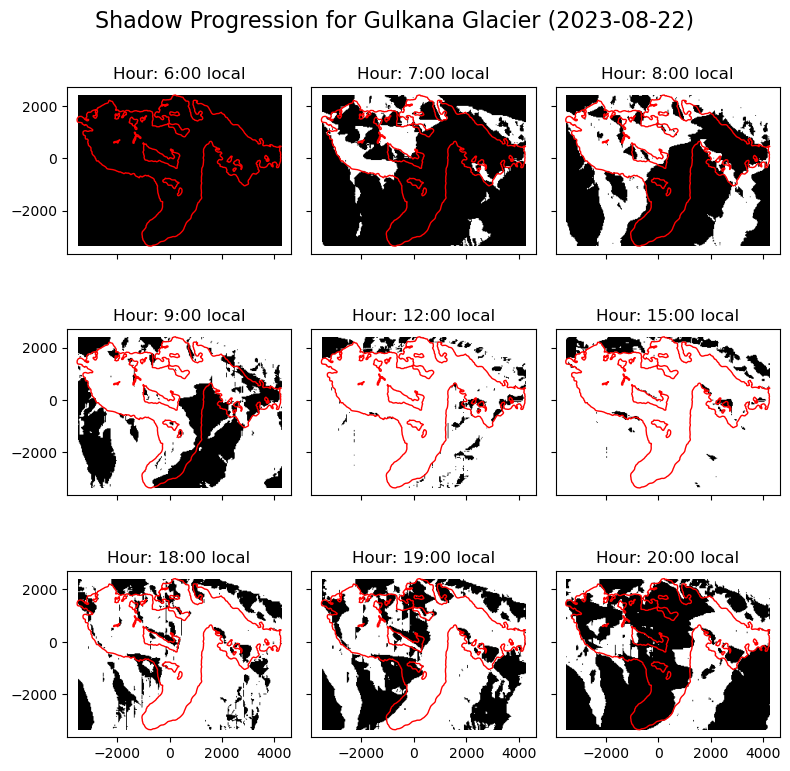

In [ ]:
shading_fp = '/home/claire/Local/data/shading/'

glacier = 'gulkana'
glacier_id = translate_rgi[glacier]['6']
date = '2023-08-22'
target_local_hours = [6, 7, 8, 9, 12, 15, 18, 19, 20]

# load the shading file
file_path = os.path.join(shading_fp, f"{glacier_id}_shadows.zarr")
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find shadow file: {file_path}")

ds = xr.open_dataset(file_path)

# apply coordinate corrections as needed
local_times = ds.time.values - np.timedelta64(8, "h")
ds = ds.assign_coords(time=local_times)
ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')
ds = ds.rio.write_crs(ds['spatial_ref'].attrs['crs_wkt'])

# select the day specified
date_doy = pd.to_datetime(date).day_of_year
glacier_day = ds.sel(time=ds.time.dt.dayofyear == date_doy)

# initialize plot
fig, axes = plt.subplots(3, 3, figsize=(8, 8), sharex=True, sharey=True)
axes = axes.flatten()

# load the RGI geodataframe for the shapefile
gdf = gpd.read_file('/home/claire/Local/RGI/rgi60/01_rgi60_Alaska/01_rgi60_Alaska.shp')
gdf = gdf.loc[gdf['RGIId'] == 'RGI60-'+glacier_id]
gdf = gdf.to_crs(ds.rio.crs)

# loop through hours
for i, hour in enumerate(target_local_hours):
    ax = axes[i]

    # select the specific hour slice
    hourly_data = glacier_day.sel(time=glacier_day.time.dt.hour == hour)

    # pull out 2D spatial grid
    shadow_grid = hourly_data['shadow_mask'].values.squeeze()

    # Plot the binary shadow map
    # sun = white, shade = black
    im = ax.imshow(
        shadow_grid,
        cmap="gray",
        extent=[
            ds.x.min().item(),
            ds.x.max().item(),
            ds.y.min().item(),
            ds.y.max().item(),
        ],
        origin="upper",
    )

    ax.set_title(f"Hour: {hour}:00 local")

    # plot the shapefile
    gdf.boundary.plot(ax=ax, edgecolor='red', linewidth=1)

fig.suptitle(
    f"Shadow Progression for {glacier.replace('_',' ').capitalize()} Glacier ({date})",
    fontsize=16, y=0.98
)
plt.tight_layout()
plt.savefig('../shadow_map.png', bbox_inches='tight', dpi=300)
plt.show()

ds.close()

### Plot seasonal mass balances

In [25]:
i = 0

all_mod_albedo = [] 
all_meas_albedo = []

for glacier in site_dict:
    for site in site_dict[glacier]:
        gn = translate_rgi[glacier]['6']
        mb = MassBalance(glacier, site)
        ab = Albedo(glacier, site, 'all')

        # ds = xr.open_dataset(f'../Output/cpu_sims/{glacier}{site}_2026_06_22_base_0.nc') 
        ds = xr.open_zarr(f'../Output/new_sims_0/{gn}_{i}.zarr')
        # assert ds.error.sum() < 1e-6

        # mb.get_model_mb(ds)
        # mb.plot_mb()
        # plt.savefig(f'../figs/{glacier}{site}_best_mb.png')
        # plt.close()
        
        ab.get_model_albedo(ds)
        # ab.get_deltas()
        for mod, meas in zip(ab.mod, ab.meas):
            all_mod_albedo.append(mod)
            all_meas_albedo.append(meas)
        # plt.savefig(f'../figs/{glacier}{site}_best_albedo.png')
        # plt.show()
        # plt.close()

        i += 1

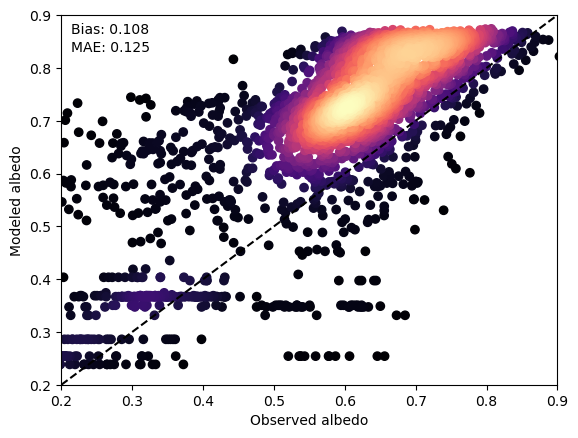

In [26]:
mod = np.array(all_mod_albedo).flatten()
meas = np.array(all_meas_albedo).flatten()

fig, ax = plt.subplots()
from scipy.stats import gaussian_kde
xy = np.vstack([mod, meas])
kde = gaussian_kde(xy)
z = kde(xy)

idx = z.argsort()
x, y, z = meas[idx], mod[idx], z[idx]

minn, maxx = 0.2, 0.9

ax.scatter(x, y, c=z, cmap='magma')
ax.plot([minn, maxx], [minn, maxx], 'k--')
bias = np.mean(mod - meas)
MAE = np.mean(np.abs((mod - meas)))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.90, f'MAE: {MAE:.3f}', transform=ax.transAxes)
ax.set_ylabel('Modeled albedo')
ax.set_xlabel('Observed albedo')
ax.set_xlim(minn, maxx)
ax.set_ylim(minn, maxx)
plt.show()

Beginning wolverine N . . .
998.0 m a.s.l. 998.0 m a.s.l.
Beginning wolverine B . . .
1058.0 m a.s.l. 1058.0 m a.s.l.
Beginning wolverine EC . . .
1348.0 m a.s.l. 1348.0 m a.s.l.
Beginning kahiltna K53 . . .
1119.0 m a.s.l. 1119.0 m a.s.l.
Beginning kahiltna K17b . . .
1934.0 m a.s.l. 1934.0 m a.s.l.
Beginning kennicott GTL . . .
1081.0 m a.s.l. 1081.0 m a.s.l.
Beginning kennicott GTH . . .
2173.0 m a.s.l. 2173.0 m a.s.l.
Beginning lemon_creek B . . .
940.0 m a.s.l. 940.0 m a.s.l.
Beginning lemon_creek C . . .
1062.0 m a.s.l. 1062.0 m a.s.l.
Beginning lemon_creek D . . .
1172.0 m a.s.l. 1172.0 m a.s.l.
Beginning taku NWB1 . . .
1502.3 m a.s.l. 1502.3 m a.s.l.
Beginning taku TKG3 . . .
1178.4 m a.s.l. 1178.4 m a.s.l.
Beginning gulkana AU . . .
1442.0 m a.s.l. 1442.0 m a.s.l.
Beginning gulkana B . . .
1682.0 m a.s.l. 1682.0 m a.s.l.
Beginning gulkana D . . .
1843.0 m a.s.l. 1843.0 m a.s.l.


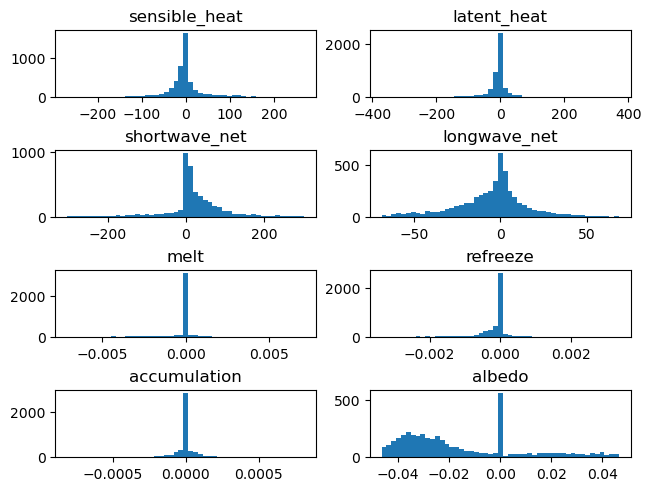

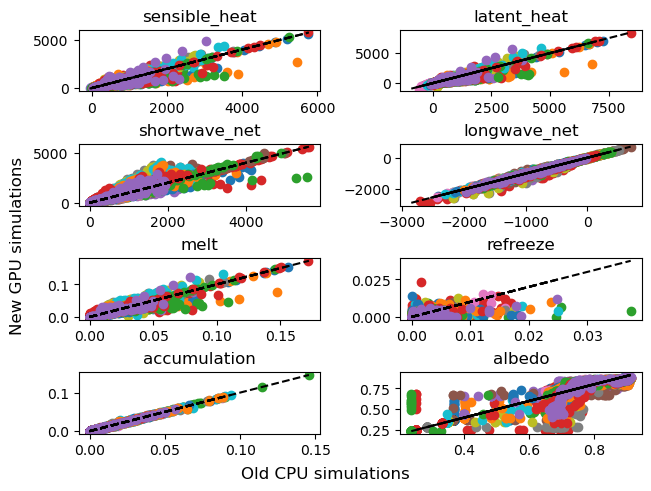

In [27]:
plot_vars = ['sensible_heat', 'latent_heat', 'shortwave_net', 'longwave_net', 'melt','refreeze','accumulation','albedo']
resample = 'D'

fig2, axes2 = plt.subplots(4, 2)
axes2 = axes2.flatten()

all_diff = {}
for var in plot_vars:
    all_diff[var] = []

fig1, axes1 = plt.subplots(4, 2)
axes1 = axes1.flatten()

i = 0
for glacier in site_dict:
    for site in site_dict[glacier]:

        print(f'Beginning {glacier} {site} . . .')

        gn = translate_rgi[glacier]['6']
        ds0 = xr.open_dataset(f'../Output/cpu_sims/{glacier}{site}_2026_06_22_base_0.nc')
        ds1 = xr.open_zarr(f'../Output/new_sims_0/{gn}_{i}.zarr')
        print(ds0.attrs['elevation'], ds1.attrs['elevation'])

        tz = 2 if glacier != 'gulkana' else 0
        ds0['time'] = ds0.time - pd.Timedelta(hours=tz)

        # common = pd.to_datetime(np.intersect1d(ds0.time.values, ds1.time.values))
        common=pd.date_range('2023-04-20','2024-04-20',freq='h')
        ds0 = ds0.sel(time=common)
        ds1 = ds1.sel(time=common)

        for v, ax1 in zip(plot_vars, axes1):
            if v == 'accumulation':
                v0 = 'accum' 
            elif v == 'shortwave_in':
                v0 = 'SWin'
            elif v == 'longwave_in':
                v0 = 'LWin'
            elif v == 'shortwave_net':
                v0 = 'SWnet'
            elif v == 'longwave_net':
                v0 = 'LWnet'
            elif v.endswith('_heat'):
                v0 = v.split('_')[0]
            else:
                v0 = v

            if resample:
                if v in ['melt','accumulation', 'refreeze'] or 'shortwave' in v or 'longwave' in v or 'heat' in v:
                    vals0 = ds0.isel(layer=0)[v0].resample(time=resample).sum().values
                    vals1 = ds1.isel(layer=0)[v].resample(time=resample).sum().values
                else:
                    vals0 = ds0.isel(layer=0)[v0].resample(time=resample).mean().values
                    vals1 = ds1.isel(layer=0)[v].resample(time=resample).mean().values
            else:
                vals0 = ds0.isel(layer=0)[v0].values 
                vals1 = ds1.isel(layer=0)[v].values

            min_value, max_value = np.min([vals0, vals1]), np.max([vals0, vals1])

            ax1.scatter(vals0, vals1, label=glacier+site)
            ax1.plot([min_value, max_value], [min_value, max_value], 'k--')
        
            diff = vals1 - vals0 
            for d in diff:
                all_diff[v].append(d)
            
            ax1.set_title(v)

        i += 1

for v, ax2 in zip(plot_vars, axes2):
    min_val = np.min(all_diff[v])
    max_val = np.max(all_diff[v])
    max_abs = max(abs(min_val), abs(max_val)) * 0.1
    ax2.hist(np.array(all_diff[v]), bins=np.linspace(-max_abs, max_abs, 50))
    ax2.set_title(v)

fig1.supxlabel('Old CPU simulations')
fig1.supylabel('New GPU simulations')
fig1.set_constrained_layout(constrained=True)
fig2.set_constrained_layout(constrained=True)
fig1.savefig('../figs/1to1.png')
fig2.savefig('../figs/histogram.png')
plt.show()

/var/folders/vp/2f8fwwhs579gkbt9hbtf2lz40000gn/T/ipykernel_12034/3883381361.py:4: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  dates = pd.date_range('2000-04-20','2001-08-20', freq='d')


(<Figure size 500x680 with 8 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

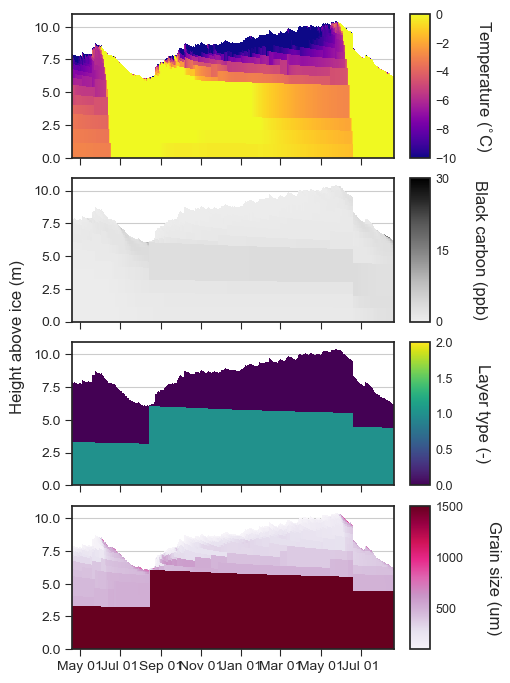

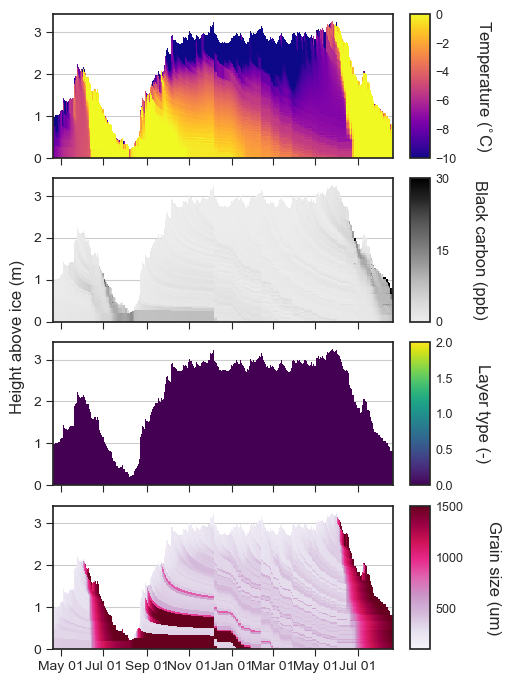

In [4]:

ds0 = xr.open_dataset(f'../Output/cpu_sims/gulkanaD_2026_06_22_base_0.nc')
ds1 = xr.open_zarr(f'../Output/new_sims_0/01.00570_14.zarr')

dates = pd.date_range('2000-04-20','2001-08-20', freq='d')
# ds0 = ds0.sel(time=dates, layer=0) # .mean('layer')
# ds1 = ds1.sel(time=dates, layer=0) # .mean('layer')

# plt.plot(ds0.time, ds0.layerBC, c='k')
# plt.plot(ds1.time, ds1.layerBC, c='r')

# plt.show()

from shop.plotting.plotting_fxns import *
visualize_layers(ds0, dates, ['layertemp','layerBC','layertype', 'layergrainsize'])
visualize_layers(ds1, dates, ['layertemp','layerBC', 'layertype', 'layergrainsize'])

In [35]:
fn_pr = '/Users/cvw/Downloads/CESM2-WACCM_ssp534-over_r1i1p1f1_pr_era5corrected.nc'
fn_tas = '/Users/cvw/Downloads/CESM2-WACCM_ssp534-over_r1i1p1f1_tas_era5corrected.nc'

ds_pr = xr.open_dataset(fn_pr)
ds_tas = xr.open_dataset(fn_tas)

ds_tas

/var/folders/vp/2f8fwwhs579gkbt9hbtf2lz40000gn/T/ipykernel_2161/2639671005.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds_pr = xr.open_dataset(fn_pr)
/var/folders/vp/2f8fwwhs579gkbt9hbtf2lz40000gn/T/ipykernel_2161/2639671005.py:5: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds_tas = xr.open_dataset(fn_tas)


<xarray.Dataset> Size: 22GB
Dimensions:  (time: 5400, lat: 721, lon: 1440)
Coordinates:
  * time     (time) object 43kB 1850-01-15 12:00:00 ... 2299-12-15 12:00:00
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
Data variables:
    tas      (time, lat, lon) float32 22GB ...
Attributes: (12/43)
    CDI:                    Climate Data Interface version 2.0.6 (https://mpi...
    source:                 CESM2 (2017): atmosphere: CAM6 (0.9x1.25 finite v...
    institution:            National Center for Atmospheric Research, Climate...
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                4
    ...                     ...
    variant_info:           CMIP6 CESM2 hindcast (1850-2014) with high-top at...
    variant_label:          r1i1p1f1
    branch_time_in_parent:  20075.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    CDO:                    Climate Data Operators version 2.0.6 (https://mpi...

In [42]:
import xarray as xr

for ds in [ds_pr, ds_tas]:
    print(f'\n=== {list(ds.variables.keys())[0]} ===')
    for name, var in ds.variables.items():
        enc = var.encoding
        print(f'{name:12s} dtype={var.dtype} '
              f'chunks={enc.get("chunksizes")} '
              f'zlib={enc.get("zlib")} level={enc.get("complevel")} '
              f'shuffle={enc.get("shuffle")} '
              f'fill={enc.get("_FillValue")}')


=== pr ===
pr           dtype=float32 chunks=None zlib=False level=0 shuffle=False fill=nan
time         dtype=object chunks=None zlib=False level=0 shuffle=False fill=nan
lat          dtype=float32 chunks=None zlib=False level=0 shuffle=False fill=nan
lon          dtype=float32 chunks=None zlib=False level=0 shuffle=False fill=nan

=== tas ===
tas          dtype=float32 chunks=(100, 50, 50) zlib=True level=1 shuffle=False fill=nan
lat          dtype=float32 chunks=None zlib=False level=0 shuffle=False fill=nan
lon          dtype=float32 chunks=None zlib=False level=0 shuffle=False fill=nan
time         dtype=object chunks=None zlib=False level=0 shuffle=False fill=nan


In [36]:
ds_pr

<xarray.Dataset> Size: 22GB
Dimensions:  (lat: 721, lon: 1440, time: 5400)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * time     (time) object 43kB 1850-01-15 12:00:00 ... 2299-12-15 12:00:00
Data variables:
    pr       (lat, lon, time) float32 22GB ...
Attributes: (12/44)
    CDI:                    Climate Data Interface version 2.0.6 (https://mpi...
    source:                 CESM2 (2017): atmosphere: CAM6 (0.9x1.25 finite v...
    institution:            National Center for Atmospheric Research, Climate...
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    tracking_id:            hdl:21.14100/2e69610a-c67a-4d36-b4df-09319901cf0c
    variable_id:            pr
    variant_info:           CMIP6 CESM2 hindcast (1850-2014) with high-top at...
    variant_label:          r1i1p1f1
    CDO:                    Climate Data Operators version 2.0.6 (https://mpi...
    units:                  kg m-2 s-1

In [ ]:
# variable = 'wind' 
# glacier = 'gulkana'
# bins = {'temp': np.arange(-40, 40), 'wind': np.arange(0, 30), 'rh': np.arange(0, 100, 5), 'SWin': np.arange(0, 3e6, 1e4)}

# for variable in ['temp','wind','SWin','rh']:
#     for glacier in ['gulkana','kahiltna','wolverine','lemon_creek']:
#         vx = variable + '_0' if variable == 'temp' else variable
#         if not os.path.exists(f'data/bias_adjustment/quantile_mapping_{glacier}_{vx}.csv'):
#             continue
#         before = pd.read_csv(f'data/bias_adjustment/quantile_mapping_{glacier}_{vx}.csv')
#         before_aws = before['mapping']
#         before_merra = before['sorted']

#         after = xr.open_dataset('data/quantile_cdfs.nc', group=variable)
#         stations = after.station.values 
#         station = [f for f in stations if f.startswith(glacier)]
#         if len(station) < 1:
#             continue
#         after_aws = after.sel(station=station[0]).aws_cdf.values 
#         after_merra = after.sel(station=station[0]).merra_cdf.values 

#         fig, axes = plt.subplots(2)
#         axes[0].hist(before_aws, bins = bins[variable], histtype='step', density=True, label='Before')
#         axes[0].hist(after_aws, bins=bins[variable], histtype='step', density=True, label='After')
#         axes[0].legend()
#         axes[0].set_title('AWS')

#         axes[1].hist(before_merra, bins = bins[variable], histtype='step', density=True, label='Before')
#         axes[1].hist(after_merra, bins=bins[variable], histtype='step', density=True, label='After')
#         axes[1].set_title('MERRA-2')
#         fig.suptitle(f'{glacier.capitalize()} {variable} bias correction before / after')
#         fig.set_constrained_layout(constrained=True)
#         plt.show()